In [1]:
#from pyaedt.hfss import Hfss
from ansys.aedt.core import Hfss
import os, copy, pprint
import numpy as np
import matplotlib.pyplot as plt

## Configuration

In [2]:

solution_type = "Modal" # "Eigenmode", "Modal"

# Common options
use_antenna = False
use_second_chip = False

# Eigen mode
n_mode = 18
copy_mesh = True

# Sweep flags
do_chip_inductance_sweep = False
do_chip_angle_sweep = True
do_chip_gap_sweep = False
do_chip_width_sweep = False
do_chip_height_sweep = False
do_outer_radius_sweep = False
do_outer_height_sweep = False
do_coax_height_sweep = False

no_variation = \
    do_chip_inductance_sweep or\
    do_chip_angle_sweep or\
    do_chip_gap_sweep or\
    do_chip_width_sweep or\
    do_chip_height_sweep or\
    do_outer_radius_sweep or\
    do_outer_height_sweep or\
    do_coax_height_sweep

## Make project and design

In [3]:
hfss = Hfss(
    project="test.aedt",
    design="A1",
    solution_type=solution_type
)

PyAEDT INFO: Python version 3.11.13 | packaged by conda-forge | (main, Jun  4 2025, 14:39:58) [MSC v.1943 64 bit (AMD64)].
PyAEDT INFO: PyAEDT version 0.17.4.
PyAEDT INFO: Initializing new Desktop session.
PyAEDT INFO: Log on console is enabled.
PyAEDT INFO: Log on file C:\Users\ymino\AppData\Local\Temp\15\pyaedt_ymino_215cb0e5-3bcb-43ff-a6be-95c17c4edbc6.log is enabled.
PyAEDT INFO: Log on AEDT is disabled.
PyAEDT INFO: Debug logger is disabled. PyAEDT methods will not be logged.
PyAEDT INFO: Launching PyAEDT with gRPC plugin.
PyAEDT ERROR: A(n) <class 'psutil.AccessDenied'> error occurred while retrieving information for the active AEDT sessions: (pid=11984, name='ansysedt.exe')
PyAEDT ERROR: A(n) <class 'psutil.AccessDenied'> error occurred while retrieving information for the active AEDT sessions: (pid=13016, name='ansysedt.exe')
PyAEDT ERROR: A(n) <class 'psutil.AccessDenied'> error occurred while retrieving information for the active AEDT sessions: (pid=16452, name='ansysedt.exe'

In [4]:
# 8.6  GHz, L = 30   nH, chip_gap = 2000 um, chip_width = 250 um, chip_height = 400 um
# 10.4 GHz, L = 20   nH, chip_gap = 2000 um, chip_width = 250 um, chip_height = 400 um
# 11.7 GHz, L = 15   nH, chip_gap = 2000 um, chip_width = 250 um, chip_height = 400 um
# 12.1 GHz, L = 13.5 nH, chip_gap = 2000 um, chip_width = 250 um, chip_height = 400 um
# 12.6 GHz, L = 13   nH, chip_gap = 2000 um, chip_width = 250 um, chip_height = 400 um
# 12.8 GHz, L = 12.5 nH, chip_gap = 2000 um, chip_width = 250 um, chip_height = 400 um
# 14.1 GHz, L = 10   nH, chip_gap = 2000 um, chip_width = 250 um, chip_height = 400 um

#  GHz, L = 10   nH, chip_gap = 20 um, chip_width = 250 um, chip_height = 4000 um

hfss["$outer_radius"] = "8mm" # 5mm, 8mm (for 10GHz cut-off)
hfss["$outer_height"] = "38mm" # 38mm
hfss["$coax_radius"] = "1.5mm" # "1.5mm"
hfss["$coax_height"] = "9mm"
hfss["$antenna_height"] = "18mm"
hfss["antenna_radius"] = "1.5mm"
hfss["$antenna_outer_height"] = "8mm"
hfss["antenna_outer_radius"] = "3mm"
hfss["$chip_inductance"] = "10nH"
hfss["$chip_gap"] = "20um" # 20um
hfss["$chip_width"] = "250um" # 250um
hfss["$chip_height"] = "4000um" # 400um (For chip_gap = 20um, galvanic with 3240 ( ~4500 with 45 degree ? ) )
hfss["$chip_theta"] = "45deg"
hfss["$chip_pos_z"] = "0.5*$coax_height"
hfss["$chip_pos_y"] = "$coax_radius + 0.5*($outer_radius - $coax_radius)"

hfss["box_height"] = "40mm"
hfss["$box_length"] = "2*$outer_radius + 10mm" #"15mm"

In [5]:
box_config = dict(
    origin = ["-$box_length/2", "-$box_length/2", "$outer_height - box_height"],
    sizes = ["$box_length", "$box_length", "box_height"],
    name = "box",
    material = "copper"
)
if use_antenna:
    box_config.update( sizes = ["$box_length", "$box_length", "box_height + $antenna_outer_height"] )

box_object = hfss.modeler.create_box( **box_config )

## Make Vacuum object
#_, vacuum_name = hfss.modeler.duplicate_around_axis(box_object, "Z", angle = 0)
vacuum_object = box_object.clone()
vacuum_object.name = "boundary"
vacuum_object = hfss.modeler.get_object_from_name("boundary")
hfss.assign_material("boundary", "vacuum")
if solution_type == "Eigenmode":
    # hfss.modeler.move_face([vacuum_object.top_face_z], offset=20) # offset in mm
    hfss.assign_finite_conductivity([vacuum_object.top_face_z],is_infinite_ground=True)

PyAEDT INFO: Modeler class has been initialized! Elapsed time: 0m 0sec
PyAEDT INFO: Materials class has been initialized! Elapsed time: 0m 0sec


In [6]:
cylinder_config = dict(
    orientation="Z" ,
    origin=[0, 0, 0], 
    radius="$outer_radius", 
    height="$outer_height", 
    name="outer", 
    material="vacuum"
)

cylinder_object = hfss.modeler.create_cylinder( **cylinder_config )

In [7]:
box_object.subtract(cylinder_object, keep_originals=False)

PyAEDT INFO: Parsing design objects. This operation can take time
PyAEDT INFO: Refreshing bodies from Object Info
PyAEDT INFO: Bodies Info Refreshed Elapsed time: 0m 0sec
PyAEDT INFO: 3D Modeler objects parsed. Elapsed time: 0m 0sec


In [8]:
cylinder_config = dict(
    orientation="Z" ,
    origin=[0, 0, 0], 
    radius="$coax_radius", 
    height="$coax_height", 
    name="coax", 
    material="copper"
)

coax_object = hfss.modeler.create_cylinder( **cylinder_config )

In [9]:
box_object.unite(coax_object)

PyAEDT INFO: Parsing design objects. This operation can take time
PyAEDT INFO: Refreshing bodies from Object Info
PyAEDT INFO: Bodies Info Refreshed Elapsed time: 0m 0sec
PyAEDT INFO: 3D Modeler objects parsed. Elapsed time: 0m 0sec
PyAEDT INFO: Union of 2 objects has been executed.


## Create antenna

In [10]:
if use_antenna:
    antenna_config = dict(
        orientation="Z" ,
        origin=[0, 0, "$outer_height"], 
        radius="antenna_outer_radius", 
        height="$antenna_outer_height", 
        name="antenna", 
        material="vacuum"
    )

    antenna_object = hfss.modeler.create_cylinder( **antenna_config )
    box_object.subtract(antenna_object, keep_originals=False)

    antenna_config = dict(
        orientation="Z" ,
        origin=[0, 0, "$outer_height + $antenna_outer_height - $antenna_height"], 
        radius="antenna_radius", 
        height="$antenna_height", 
        name="core", 
        material="copper"
    )

    core_object = hfss.modeler.create_cylinder( **antenna_config )

## Create chip

In [11]:
chip_coord = hfss.modeler.create_coordinate_system(origin = [0, "$chip_pos_y","$chip_pos_z"], name = "chip_coord")
chip_coord.set_as_working_cs()
cap1 = hfss.modeler.create_rectangle(origin = ["-0.5*$chip_width", "0.5*$chip_gap", 0], sizes = ["$chip_width", "$chip_height"], name = "cap1", orientation="XY")
cap2 = hfss.modeler.create_rectangle(origin = ["-0.5*$chip_width", "-0.5*$chip_gap - $chip_height", 0], sizes =  ["$chip_width", "$chip_height"], name = "cap2", orientation="XY")

In [12]:
## Only for newer pyaedt versions ?
hfss.assign_perfect_e("box")
hfss.assign_perfect_e("cap1")
hfss.assign_perfect_e("cap2")
if use_antenna:
    hfss.assign_perfect_e("core")

PyAEDT INFO: Boundary Perfect E PerfectE_box has been created.
PyAEDT INFO: Boundary Perfect E PerfectE_cap1 has been created.
PyAEDT INFO: Boundary Perfect E PerfectE_cap2 has been created.


## Create ports

In [13]:
# faces = vacuum_object.faces
# top_face = max(faces, key=lambda f: f.center[2])

In [14]:
hfss.modeler.set_working_coordinate_system("Global")
if solution_type=="Modal":
    if use_antenna:
        port_in = hfss.modeler.create_circle(origin = [0, 0, "$outer_height + $antenna_outer_height"], radius = "antenna_outer_radius", name = "port_in", orientation="XY")
        hfss.lumped_port(assignment="port_in", integration_line = hfss.AxisDir.YNeg, name="Port_in")
    else:
        port_in = hfss.modeler.create_circle(origin = [0, 0, "$outer_height"], radius = "$outer_radius", name = "port_in", orientation="XY")
        hfss.wave_port(assignment="port_in", name = "Port_in")

hfss.modeler.set_working_coordinate_system("chip_coord")
port_out = hfss.modeler.create_rectangle(origin = ["-10um","-0.5*$chip_gap" ], sizes=["20um","$chip_gap"], name = "port_out", orientation="XY")
if solution_type=="Eigenmode":
    sheet = hfss.assign_lumped_rlc_to_sheet(assignment="port_out", 
                                    start_direction=hfss.AxisDir.YNeg, 
                                    inductance=9e-9, name="Port_out")
    sheet.update_property(
        prop_name = "Inductance",
        prop_value = "$chip_inductance"
    )
else:
    # hfss.assign_lumped_rlc_to_sheet(assignment="port_out", start_direction=hfss.AxisDir.YNeg, inductance=chip_inductance, name="Port_out")
    hfss.lumped_port(assignment="port_out", integration_line = hfss.AxisDir.YNeg, name="Port_out")

PyAEDT INFO: Boundary Wave Port Port_in has been created.
PyAEDT INFO: Boundary Lumped Port Port_out has been created.


## Rotate chip

In [15]:
hfss.modeler.set_working_coordinate_system("chip_coord")
hfss.modeler.rotate(assignment=["cap1","cap2","port_out"], axis="X", angle="$chip_theta")

True

In [16]:
if use_second_chip:
    hfss.modeler.set_working_coordinate_system("Global")
    _, object_name = hfss.modeler.duplicate_around_axis(["cap1","cap2","port_out"], "Z", angle = 90)
    cap1_object = hfss.modeler.get_object_from_name(object_name[0])
    cap1_object.name = "chip2_cap1"
    cap2_object = hfss.modeler.get_object_from_name(object_name[1])
    cap2_object.name = "chip2_cap2"
    port_object = hfss.modeler.get_object_from_name(object_name[2])
    port_object.name = "chip2_port_out"

## Assign mesh operation

In [17]:
hfss.mesh.assign_length_mesh(["cap1", "cap2"], maximum_length="0.1mm")
hfss.mesh.assign_length_mesh(["port_out"], maximum_length="10um") # maximum 7um for JJ in qiskit-metal
if use_second_chip:
    hfss.mesh.assign_length_mesh(["chip2_cap1","chip2_cap2"], maximum_length="0.1mm")
    hfss.mesh.assign_length_mesh(["chip2_port_out"], maximum_length="10um")

PyAEDT INFO: Mesh class has been initialized! Elapsed time: 0m 0sec
PyAEDT INFO: Mesh class has been initialized! Elapsed time: 0m 0sec


## Create Analysis Setup

In [18]:
# if solution_type=="Modal":
#     hfss.create_open_region(Frequency="1GHz")

if solution_type=="Modal":

    setup = hfss.create_setup("MySetup") 
    setup.create_frequency_sweep(
        unit="GHz",
        name="Sweep1",
        start_frequency=3.0,
        stop_frequency=30.0,
        sweep_type="Interpolating",
    )

PyAEDT INFO: Parsing C:/HFSS/ymino/test.aedt.
PyAEDT INFO: File C:/HFSS/ymino/test.aedt correctly loaded. Elapsed time: 0m 0sec
PyAEDT INFO: aedt file load time 0.10513830184936523
PyAEDT INFO: Linear count sweep Sweep1 has been correctly created


In [19]:
if solution_type=="Eigenmode":
    setup = hfss.create_setup("MySetup") 
    setup.props["MinimumFrequency"] = "2GHz" 
    setup.props["NumModes"] = n_mode
    setup.props["MaximumPasses"] = 10
    print(setup.props)

In [20]:
if not no_variation:
    hfss.analyze_setup(name = "MySetup", cores=8)

In [21]:
if do_chip_inductance_sweep:
    sweep = hfss.parametrics.add(
        variable="$chip_inductance",
        start_point="16nH", # 5nH
        end_point="20nH", # 30nH
        step="1nH",
        variation_type="LinearStep",
        name="ChipInductance"
    )
    sweep.add_variation(
        sweep_variable="$chip_inductance",
        start_point=10.5,
        end_point=15,
        step=0.5,
        units="nH",
        variation_type="LinearStep",
    )
    sweep.add_variation(
        sweep_variable="$chip_inductance",
        start_point=5.25,
        end_point=10,
        step=0.25,
        units="nH",
        variation_type="LinearStep",
    )
    sweep.add_variation(
        sweep_variable="$chip_inductance",
        start_point=1,
        end_point=5,
        step=0.2,
        units="nH",
        variation_type="LinearStep",
    )

    ## You can check the available properties
    # print(sweep.props)
    ## If you want to enable SaveFields & CopyMesh, you need to directly rewrite the properties using the dictionary
    # hfss.set_oo_property_value(
    #     aedt_object=hfss.ooptimetrics, 
    #     object_name="ChipInductance", 
    #     prop_name='SaveFields', 
    #     value='True')
    sweep.props["ProdOptiSetupDataV2"]["SaveFields"] = True
    sweep.props["ProdOptiSetupDataV2"]["CopyMesh"] = copy_mesh
    sweep.analyze(cores = 8)

In [ ]:
if do_chip_angle_sweep:
    sweep = hfss.parametrics.add(
        variable="$chip_theta",
        start_point="0deg",
        end_point="90deg",
        step=3,
        name="ChipAngle"
    )
    hfss.set_oo_property_value(
        aedt_object=hfss.ooptimetrics, 
        object_name="ChipAngle", 
        prop_name='SaveFields', 
        value='True')
    sweep.analyze(cores = 8)

PyAEDT INFO: Key Desktop/ActiveDSOConfigurations/HFSS correctly changed.
PyAEDT INFO: Solving Optimetrics
PyAEDT INFO: Design setup ChipAngle solved correctly in 0.0h 14.0m 4.0s


In [ ]:
if do_chip_gap_sweep:
    sweep = hfss.parametrics.add(
        variable="$chip_gap",
        start_point="20um",
        end_point="4000um",
        step=10,
        name="ChipGap"
    )
    hfss.set_oo_property_value(
        aedt_object=hfss.ooptimetrics, 
        object_name="ChipGap", 
        prop_name='SaveFields', 
        value='True')
    sweep.analyze(cores = 8)

In [ ]:
if do_chip_width_sweep:
    sweep = hfss.parametrics.add(
        variable="$chip_width",
        start_point="250um",
        end_point="2000um",
        step=5,
        name="ChipWidth"
    )
    hfss.set_oo_property_value(
        aedt_object=hfss.ooptimetrics, 
        object_name="ChipWidth", 
        prop_name='SaveFields', 
        value='True')
    sweep.analyze(cores = 8)

In [ ]:
if do_chip_height_sweep:
    sweep = hfss.parametrics.add(
        variable="$chip_height",
        start_point="400um",
        end_point="4000um",
        step=5,
        name="ChipHeight"
    )
    hfss.set_oo_property_value(
        aedt_object=hfss.ooptimetrics, 
        object_name="ChipHeight", 
        prop_name='SaveFields', 
        value='True')
    sweep.analyze(cores = 8)

In [ ]:
if do_outer_radius_sweep:
    radius_sweep = hfss.parametrics.add(
        variable="$outer_radius",
        start_point="5mm",
        end_point="15mm",
        step=6,
        name="Radius"
    )
    radius_sweep.analyze(cores = 8)

In [ ]:
if do_outer_height_sweep:
    radius_sweep = hfss.parametrics.add(
        variable="$outer_height",
        start_point="18mm",
        end_point="38mm",
        step=11,
        name="OuterHeight"
    )
    hfss.set_oo_property_value(
        aedt_object=hfss.ooptimetrics, 
        object_name="OuterHeight", 
        prop_name='SaveFields', 
        value='True')
    radius_sweep.analyze(cores = 8)

In [ ]:
if do_coax_height_sweep:
    height_sweep = hfss.parametrics.add(
        variable="$coax_height",
        start_point="9mm",
        end_point="38mm",
        step=3,
        name="Coax_height"
    )
    height_sweep.analyze(cores = 8)

## Produce Report

In [29]:
if solution_type == "Modal":
    report_config = dict(
        #expressions=["db(S12)"], 
        expressions=["db(S(Port_out,Port_in))","db(S(Port_out1,Port_in))"], 
        plot_name="S-parameter", 
        variations={
            "Freq": ["All"],
        }
    )
else:
    report_config = dict(
        # expressions=["Mode(1)","Mode(2)","Mode(3)"], 
        plot_name="Eigen modes", 
        variations={}
    )

if do_chip_inductance_sweep:
    report_config["variations"]["$chip_inductance"] = ["All"]
if do_chip_angle_sweep:
    report_config["variations"]["$chip_theta"] = ["All"] # ["0deg","90deg"]
if do_chip_gap_sweep:
    report_config["variations"]["$chip_gap"] = ["All"]
if do_chip_width_sweep:
    report_config["variations"]["$chip_width"] = ["All"]
if do_chip_height_sweep:
    report_config["variations"]["$chip_height"] = ["All"]
if do_outer_radius_sweep:
    report_config["variations"]["$outer_radius"] = ["All"]
if do_outer_height_sweep:
    report_config["variations"]["$outer_height"] = ["All"]
if do_coax_height_sweep:
    report_config["variations"]["$coax_height"] = ["All"]

report = hfss.post.create_report( **report_config )

PyAEDT INFO: PostProcessor class has been initialized! Elapsed time: 0m 0sec
PyAEDT INFO: PostProcessor class has been initialized! Elapsed time: 0m 0sec
PyAEDT INFO: Post class has been initialized! Elapsed time: 0m 0sec


In [30]:
# traces_to_plot = hfss.get_traces_for_plot()
# report = hfss.post.create_report(traces_to_plot)  # Creates a report in HFSS
# solution = report.get_solution_data()
# solution.plot(solution.expressions[1])  # Matplotlib axes object.

PyAEDT INFO: Solution Data Correctly Loaded.
['db(S(Port_out,Port_in))']
401
[{'$chip_theta': 0deg}, {'$chip_theta': 0.7853981633974483deg}, {'$chip_theta': 1.570796326794897deg}]
401
401
401


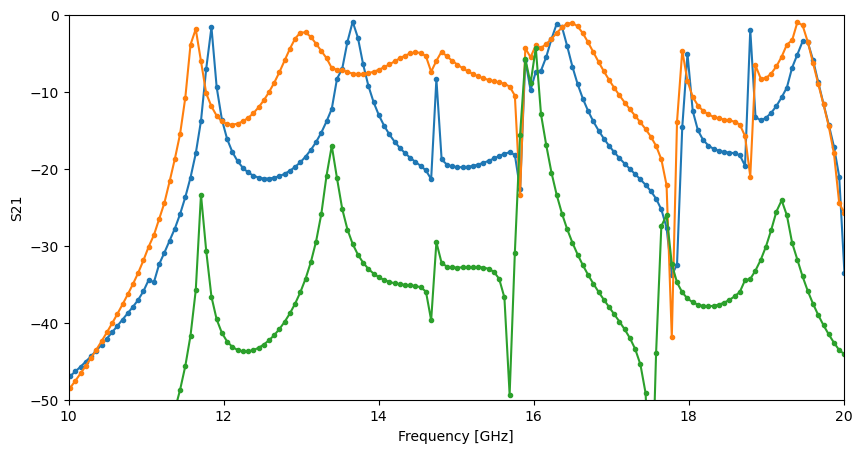

In [ ]:
if solution_type == "Modal":
    expressions=["db(S(Port_out,Port_in))"]
    # report = hfss.post.reports_by_category.eigenmode(expressions=expressions)
    solution_data = report.get_solution_data()
    solution_data.export_data_to_csv(output="CoaxCavity_Modal.csv")
    # Get S21 data
    print(report.expressions)

    # Get frequency list
    freq_list = [ i.value for i in solution_data.variation_values(variation="Freq") ]

    if not no_variation:
        S = solution_data.data_real()
        plt.figure(figsize=(10,5))
        plt.subplot(111, xlabel = "Frequency [GHz]", ylabel = "S21")
        plt.plot(freq_list, S, marker = ".")
        plt.xlim(10,20)
        plt.ylim(-50,0)
    else:
        print(solution_data.variations)
        mode_S_array = np.zeros(shape=(len(solution_data.variations), len(freq_list)))
        # First retrieve all information
        for id in range(len(solution_data.variations)):
            solution_data.set_active_variation(id)
            mode_S_array[id] = solution_data.data_real()

        plt.figure(figsize=(10,5))
        plt.subplot(111, xlabel = "Frequency [GHz]", ylabel = "S21")
        for id in range(len(solution_data.variations)):
            plt.plot(freq_list, mode_S_array[id], marker = ".")
        plt.xlim(10,20)
        plt.ylim(-70,0)

In [ ]:
solution_data = report.get_solution_data()
for id in range(len(solution_data.variations)):
    print(solution_data.variations[id])
    solution_data.set_active_variation(id)

PyAEDT INFO: Solution Data Correctly Loaded.
{}


In [ ]:
if solution_type == "Eigenmode":
    # report = hfss.post.reports_by_category.eigenmode(expressions=expressions)
    solution_data = report.get_solution_data()
    solution_data.export_data_to_csv(output="CoaxCavity_Eigenmode.csv")

    max_freq_list = []
    max_Q_list = []
    next_freq_list = []
    next_Q_list = []
    mode_freq_array = np.zeros(shape=(len(report.expressions), len(solution_data.variations)))
    mode_Q_array = np.zeros(shape=(len(report.expressions), len(solution_data.variations)))

    # First retrieve all information
    for id in range(len(solution_data.variations)):
         solution_data.set_active_variation(id)
         for imode, mode in enumerate(report.expressions):
            freq = solution_data.data_real(mode)[0]
            Q = abs(0.5 * freq / solution_data.data_imag(mode)[0])
            mode_freq_array[imode][id] = freq
            mode_Q_array[imode][id] = Q
    # Get unrelated mode info
    if copy_mesh:
        tol = 0.1e+9
    else:
        tol = 0.05e+9
    flat = mode_freq_array.flatten()
    groups = []
    averages = []
    used = set()

    min_count = int(0.8*len(solution_data.variations))
    for i, val in enumerate(flat):
        if i in used:
            continue
        close_idx = np.where(np.abs(flat - val) <= tol)[0]
        if len(close_idx) >= min_count:  # 指定回数以上出現した場合のみ
            group_vals = flat[close_idx]
            avg = np.mean(group_vals)
            groups.append(group_vals.tolist())
            averages.append(avg)
            used.update(close_idx)

    print("average:")
    pprint.pprint(averages)


    for id in range(len(solution_data.variations)):
        #print(solution_data.variations[id])
        solution_data.set_active_variation(id)

        max_Q = 1
        max_freq = 1
        next_Q = 1
        next_freq = 1
        for imode, mode in enumerate(report.expressions):
            freq = solution_data.data_real(mode)[0]
            Q = abs(0.5 * freq / solution_data.data_imag(mode)[0])
            if any(np.abs(np.array(averages) - freq) <= tol):
                continue
            if Q > max_Q:
                next_Q = copy.copy(max_Q)
                next_freq = copy.copy(max_freq)
                max_Q = copy.copy(Q)
                max_freq = copy.copy(freq)
            elif Q > next_Q:
                next_Q = copy.copy(Q)
                next_freq = copy.copy(freq)

        max_freq_list.append(max_freq)
        max_Q_list.append(max_Q)
        next_freq_list.append(next_freq)
        next_Q_list.append(next_Q)
        # print("Max  Frequency : ",max_freq*1e-9, " [GHz]")
        # print("Max  Q-value   : ",max_Q*1e-6, "M")
        # print("Next Frequency : ",next_freq*1e-9, " [GHz]")
        # print("Next Q-value   : ",next_Q*1e-6, "M")


    variation_list = []
    for my_dict in solution_data.variations:
        new_list = [ i.value for i in list(my_dict.values()) ]
        variation_list.extend(new_list)

    # Make plots
    variation_list = np.array(variation_list)
    max_freq_list = np.array(max_freq_list)
    next_freq_list = np.array(next_freq_list)
    max_Q_list = np.array(max_Q_list)
    next_Q_list = np.array(next_Q_list)
    max_lifetime_list = 2*max_Q_list/max_freq_list
    next_lifetime_list = 2*next_Q_list/next_freq_list
    plt.figure(figsize=(10,5))
    plt.subplot(121, xlabel = "Inductance [nH]", ylabel = "Frequency [GHz]")
    for imode, mode in enumerate(report.expressions):
        plt.plot(variation_list*1e9, mode_freq_array[imode]*1e-9, marker = ".")

    plt.subplot(122, xlabel = "Inductance [nH]", ylabel = "Q value")
    for imode, mode in enumerate(report.expressions):
        plt.plot(variation_list*1e9, mode_Q_array[imode], marker = ".")
    plt.yscale('log')

    plt.figure(figsize=(15,5))
    plt.subplot(131, xlabel = "Inductance [nH]", ylabel = "Frequency [GHz]")
    plt.plot(variation_list*1e9, max_freq_list*1e-9, marker=".", linestyle='None')
    #plt.plot(variation_list*1e9, next_freq_list*1e-9, marker=".")

    plt.subplot(132, xlabel = "Frequency [GHz]", ylabel = "Q Value")
    plt.plot(max_freq_list*1e-9, max_Q_list, marker=".", linestyle='None')
    #plt.plot(next_freq_list*1e-9, next_Q_list, marker=".")
    plt.yscale('log')

    plt.subplot(133, xlabel = "Frequency [GHz]", ylabel = "Lifetime [us]")
    plt.plot(max_freq_list*1e-9, max_lifetime_list*1e6, marker=".", linestyle='None')
    #plt.plot(next_freq_list*1e-9, next_Q_list, marker=".")
    plt.yscale('log')

In [ ]:
## Get intrinsic information (First you need the solution frequency)
intrinsics = hfss.setups[0].default_intrinsics
print(intrinsics)
print(hfss.setups)
solution = hfss.setups[0].get_solution_data()
# intrinsics["Freq"] = hfss.setups[0].properties["Solution Freq"]

{'Freq': '5GHz', 'Phase': '0deg'}
[MySetup with 2 Sweeps]
PyAEDT INFO: Solution Data Correctly Loaded.


In [ ]:
## Plot field (Currently disabled)
# cutlist = ["Global:YZ"]
# setup_name = hfss.existing_analysis_sweeps[0]
# #setup_name = "Sweep1"
# quantity_name = "Mag_E"
# intrinsic = {"Freq": "5GHz", "Phase": "0deg"}
# hfss.logger.info("Generating the image")
# plot_obj = hfss.post.plot_field(
#         quantity="Mag_E",
#         assignment=cutlist,
#         plot_type="CutPlane",
#         setup=setup_name,
#         intrinsics=intrinsic
#     )

In [ ]:
#field_plot = hfss.post.create_fieldplot_volume( ["boundary"],"Mag_E", plot_name="boundary_Mag")
plane_plot = hfss.post.create_fieldplot_cutplane("Global:YZ", "Mag_E", plot_name = "plane_Mag")

PyAEDT INFO: Active Design set to A1


In [ ]:
if solution_type=="Modal":
    # sweeps = hfss.get_sweeps("MySetup")
    # sweep = hfss.setups[0].sweeps[0]
    # print(sweep.frequencies)

    ooptimetric = hfss.get_oo_object(aedt_object=hfss.ooptimetrics, object_name="ChipGap")
    print(hfss.get_oo_properties(aedt_object=hfss.ooptimetrics, object_name="ChipGap"))
    print(hfss.get_oo_property_value(aedt_object=hfss.ooptimetrics, object_name="ChipGap", prop_name="IncludedVariables"))
    print(ooptimetric)

    # plane_plot.delete()
    # plane_plot = hfss.post.create_fieldplot_cutplane("Global:YZ", "Mag_E", plot_name = "plane_Mag", setup="MySetup: Sweep1")

[]
None
False


In [ ]:
if solution_type=="Eigenmode":
    sources = {"1": "0", "2": "0", "3": "1"}
    hfss.edit_sources(sources, eigenmode_stored_energy=True)

    min_value = hfss.post.get_scalar_field_value("Mag_E","Minimum")
    max_value = hfss.post.get_scalar_field_value("Mag_E","Maximum")
    print(max_value, min_value)

    plane_plot.change_plot_scale(maximum_value=max_value, minimum_value=1, is_log=True)
    # hfss.post.change_field_plot_scale(plot_name="plane_Mag1", maximum_value=max_value, minimum_value=1, is_log=True )

In [ ]:
## The following function is correct, but doesn't work due to PyVista...
# hfss.post.plot_field(
#     quantity="Mag_E",
#     assignment="Global:YZ",
#     plot_type="CutPlane",
#     log_scale=True,
# )